In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

In [2]:
train_data = pd.read_csv("/kaggle/input/nlp-getting-started/train.csv")
test_data = pd.read_csv("/kaggle/input/nlp-getting-started/test.csv")

train_labels = train_data.pop("target")

In [3]:
train_data.fillna("0", inplace=True)
test_data.fillna("0", inplace=True)

In [4]:
train_data.head()

,id,keyword,location,text
0,1,0,0,Our Deeds are the Reason of this #earthquake M...
1,4,0,0,Forest fire near La Ronge Sask. Canada
2,5,0,0,All residents asked to 'shelter in place' are ...
3,6,0,0,"13,000 people receive #wildfires evacuation or..."
4,7,0,0,Just got sent this photo from Ruby #Alaska as ...


In [5]:
test_data.head()

,id,keyword,location,text
0,0,0,0,Just happened a terrible car crash
1,2,0,0,"Heard about #earthquake is different cities, s..."
2,3,0,0,"there is a forest fire at spot pond, geese are..."
3,9,0,0,Apocalypse lighting. #Spokane #wildfires
4,11,0,0,Typhoon Soudelor kills 28 in China and Taiwan


In [6]:
train_data[train_labels == 0]["text"].values[1]

'I love fruits'

In [7]:
train_data[train_labels == 1]["text"].values[1:5]

array(['Forest fire near La Ronge Sask. Canada',
       "All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected",
       '13,000 people receive #wildfires evacuation orders in California ',
       'Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school '],
      dtype=object)

In [8]:
train_data.shape

(7613, 4)

In [9]:
test_data.shape

(3263, 4)

In [10]:
train_labels.value_counts()

0    4342
1    3271
Name: target, dtype: int64

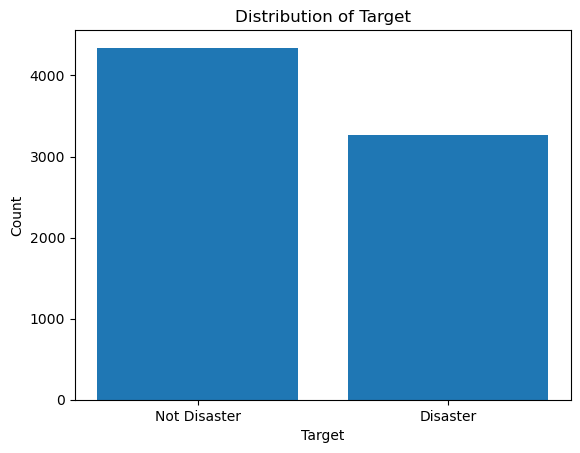

In [11]:
target_counts = train_labels.value_counts()

# Create a bar plot
plt.bar(target_counts.index, target_counts.values)
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks(target_counts.index, ['Not Disaster', 'Disaster'])
plt.title('Distribution of Target')
plt.show()

In [12]:
# Convert train_data to tf.data.Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((train_data['text'] + train_data['keyword'] + train_data['location'], train_labels))

# Convert test_data to tf.data.Dataset
test_dataset = tf.data.Dataset.from_tensor_slices(test_data['text'] + test_data['keyword'] + test_data['location'])

print("Train dataset element spec:", train_dataset.element_spec)
print("Test dataset element spec:", test_dataset.element_spec)

Train dataset element spec: (TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))
Test dataset element spec: TensorSpec(shape=(), dtype=tf.string, name=None)


In [13]:
BUFFER_SIZE = 4000
BATCH_SIZE = 64

In [14]:
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [15]:
for example, label in train_dataset.take(1):
    print('texts: ', example.numpy()[:3])
    print()
    print('labels: ', label.numpy()[:3])

texts:  [b'Two giant cranes holding a bridge collapse into nearby homes http://t.co/9asc1hhFNJbridge%20collapse0'
 b'@Collapsed thank ucollapsedLive m\xc3\x8c\xc3\x81s'
 b'#hot#teen#nsfw#porn#milf: Oiled Up Ass Hole Is Destroyed With King Size Cock Closeup Sex Clip http://t.co/faoGxkwdpGdestroyed0']

labels:  [1 0 0]


In [16]:
VOCAB_SIZE = 5000
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE)
encoder.adapt(train_dataset.map(lambda text, label: text))

In [17]:
vocab = np.array(encoder.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 'the', 'a', 'in', 'to', 'of', 'and', 'i', 'is', 'for',
       'on', 'you', 'my', 'with', 'that', 'at', 'it', 'by', 'this'],
      dtype='<U49')

In [18]:
encoded_example = encoder(example)[:3].numpy()
encoded_example

array([[ 113,  843, 1372, 1085,    3,  368,  167,   65,  655,  203,    1,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0],
       [ 475,  517,    1,    1,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0],
       [   1,    1,   30,  477, 2713,    9,  660,   14, 1257, 1984, 3457,
           1, 1120, 2814,    1,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0]])

In [19]:
for n in range(3):
    print("Original: ", example[n].numpy())
    print("Round-trip: ", " ".join(vocab[encoded_example[n]]))
    print()

Original:  b'Two giant cranes holding a bridge collapse into nearby homes http://t.co/9asc1hhFNJbridge%20collapse0'
Round-trip:  two giant cranes holding a bridge collapse into nearby homes [UNK]                  

Original:  b'@Collapsed thank ucollapsedLive m\xc3\x8c\xc3\x81s'
Round-trip:  collapsed thank [UNK] [UNK]                         

Original:  b'#hot#teen#nsfw#porn#milf: Oiled Up Ass Hole Is Destroyed With King Size Cock Closeup Sex Clip http://t.co/faoGxkwdpGdestroyed0'
Round-trip:  [UNK] [UNK] up ass hole is destroyed with king size cock [UNK] sex clip [UNK]              



In [20]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(len(encoder.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,  return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
])

In [21]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

In [22]:
history = model.fit(train_dataset, epochs=20, batch_size=64)

Epoch 1/20
119/119 [==============================] - 39s 162ms/step - loss: 1.1771 - accuracy: 0.5936
Epoch 2/20
119/119 [==============================] - 10s 83ms/step - loss: 1.0254 - accuracy: 0.7067
Epoch 3/20
119/119 [==============================] - 4s 36ms/step - loss: 0.8745 - accuracy: 0.7996
Epoch 4/20
119/119 [==============================] - 5s 42ms/step - loss: 0.7575 - accuracy: 0.8525
Epoch 5/20
119/119 [==============================] - 5s 45ms/step - loss: 0.6629 - accuracy: 0.8898
Epoch 6/20
119/119 [==============================] - 4s 36ms/step - loss: 0.5857 - accuracy: 0.9187
Epoch 7/20
119/119 [==============================] - 4s 35ms/step - loss: 0.5220 - accuracy: 0.9367
Epoch 8/20
119/119 [==============================] - 4s 36ms/step - loss: 0.4703 - accuracy: 0.9500
Epoch 9/20
119/119 [==============================] - 4s 33ms/step - loss: 0.4260 - accuracy: 0.9620
Epoch 10/20
119/119 [==============================] - 4s 34ms/step - loss: 0.3933 - acc

In [23]:
pred = model.predict(test_dataset)

threshold = 0.5

binary_pred = np.where(pred > threshold, 1, 0)
binary_pred

51/51 [==============================] - 6s 8ms/step


array([[1],
       [1],
       [1],
       ...,
       [1],
       [1],
       [0]])

In [24]:
sample_submission = pd.read_csv("/kaggle/input/nlp-getting-started/sample_submission.csv")
sample_submission["target"] = binary_pred
sample_submission.to_csv("submission.csv", index=False)

# Thanks :)